# 02 · Exploratory Data Analysis
A first look at the cleaned dataset — funnel shape, seasonality, and the relationships the downstream models will need to learn.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/adcore_clean.csv', parse_dates=['timestamp'])
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
user_id,150000.0,549666.269320,259667.221041,100001.00,324899.00,549442.00,773859.7500,999962.00000
age,150000.0,43.516693,17.734713,13.00,28.00,44.00,59.0000,74.00000
content_id,150000.0,5492.794380,2596.236975,1000.00,3245.00,5491.00,7742.0000,9998.00000
content_duration,150000.0,35.451159,19.119428,2.00,21.60,35.00,48.5000,127.20000
campaign_id,150000.0,5500.410747,287.777416,5000.00,5252.00,5502.00,5749.0000,5998.00000
bid_amount,150000.0,5.593855,2.788386,0.21,3.56,5.14,7.1225,27.28000
impressions,150000.0,6.001740,3.165803,1.00,3.00,6.00,9.0000,11.00000
clicks,150000.0,0.278060,0.588420,0.00,0.00,0.00,0.0000,11.00000
conversions,150000.0,0.040133,0.201204,0.00,0.00,0.00,0.0000,3.00000
clicked,150000.0,0.231120,0.421550,0.00,0.00,0.00,0.0000,1.00000


## Revenue by device type

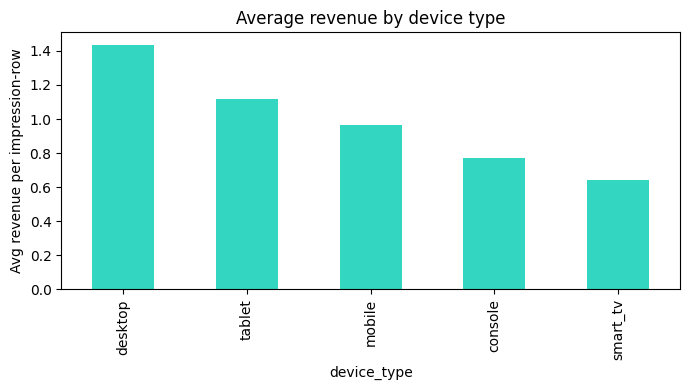

In [2]:
rev_by_device = df.groupby('device_type')['revenue'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
rev_by_device.plot(kind='bar', ax=ax, color='#33D6C0')
ax.set_ylabel('Avg revenue per impression-row')
ax.set_title('Average revenue by device type')
plt.tight_layout(); plt.show()

## Click-through rate by content genre

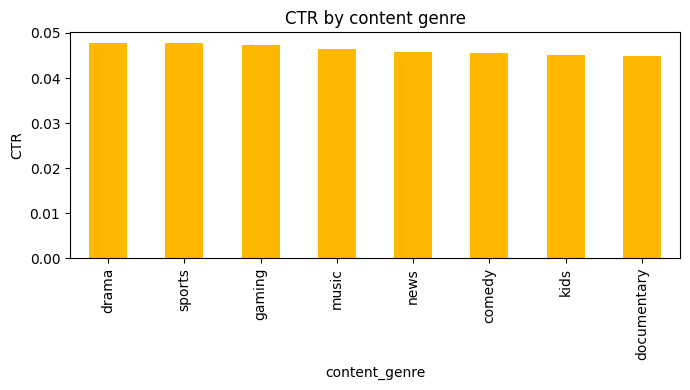

In [3]:
ctr_by_genre = (df.groupby('content_genre').apply(
    lambda g: g['clicks'].sum() / g['impressions'].sum(), include_groups=False)
    .sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(7,4))
ctr_by_genre.plot(kind='bar', ax=ax, color='#FFB800')
ax.set_ylabel('CTR')
ax.set_title('CTR by content genre')
plt.tight_layout(); plt.show()

## Daily revenue trend with 7-day rolling average

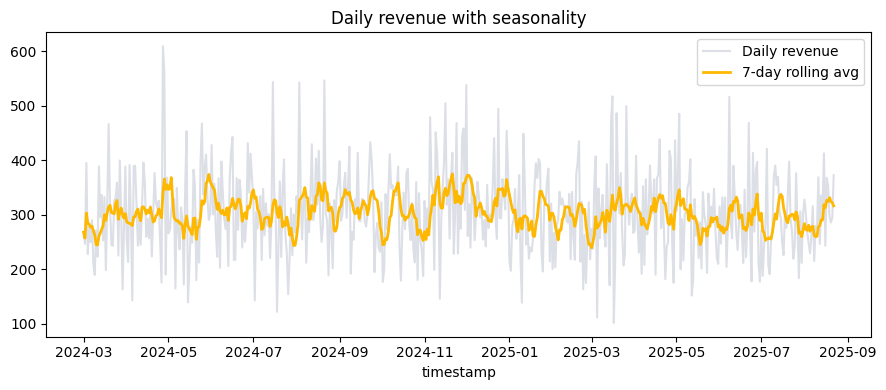

In [4]:
daily = df.groupby(df['timestamp'].dt.date)['revenue'].sum()
rolling = daily.rolling(7, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(9,4))
daily.plot(ax=ax, alpha=0.3, color='#8C96AF', label='Daily revenue')
rolling.plot(ax=ax, color='#FFB800', linewidth=2, label='7-day rolling avg')
ax.legend(); ax.set_title('Daily revenue with seasonality')
plt.tight_layout(); plt.show()

## Engagement funnel: impressions → clicks → conversions

In [5]:
funnel = pd.Series({
    'Impressions': df['impressions'].sum(),
    'Clicks': df['clicks'].sum(),
    'Conversions': df['conversions'].sum(),
})
print(funnel)
print(f"\nOverall CTR: {funnel['Clicks']/funnel['Impressions']:.2%}")
print(f"Overall CVR: {funnel['Conversions']/funnel['Clicks']:.2%}")

Impressions    900261
Clicks          41709
Conversions      6020
dtype: int64

Overall CTR: 4.63%
Overall CVR: 14.43%
